# News Headline Scraper & Analyzer for German Energy

**Purpose:** Fetch German energy news headlines via NewsAPI.org, analyze with BERTopic, and refine keywords for production, consumption, and policy topics.

**Approach:** Start broad → Analyze topics → Manually refine keywords → Test combinations


## 1. Setup & Configuration


In [54]:
# Core libraries
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import time
from typing import List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Deep translator for English to German translation
try:
    from deep_translator import GoogleTranslator
    translator_available = True
    print("✓ deep-translator imported successfully")
except ImportError:
    translator_available = False
    print("✗ deep-translator not found. Installing...")
    print("Please run: pip install deep-translator")

# API imports
from newsapi import NewsApiClient

# Environment variables
import os
from dotenv import load_dotenv

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# BERTopic for topic modeling
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    bertopic_available = True
    print("✓ BERTopic and sentence-transformers imported successfully")
except ImportError:
    bertopic_available = False
    print("✗ BERTopic not found. Installing...")
    print("Please run: pip install bertopic sentence-transformers")

# Deep translator for English to German translation
try:
    from deep_translator import GoogleTranslator
    translator_available = True
    print("✓ deep-translator imported successfully")
except ImportError:
    translator_available = False
    print("✗ deep-translator not found. Installing...")
    print("Please run: pip install deep-translator")

# Load environment variables from .env file
load_dotenv()

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("colorblind")

print("\n" + "="*60)
print("SETUP COMPLETE")
print("="*60)
print("✓ Core libraries imported successfully")
print(f"✓ Environment variables loaded from .env file")
if not bertopic_available:
    print("\n⚠️  Missing BERTopic - install with: pip install bertopic sentence-transformers")
print("="*60)


✓ deep-translator imported successfully
✓ BERTopic and sentence-transformers imported successfully
✓ deep-translator imported successfully

SETUP COMPLETE
✓ Core libraries imported successfully
✓ Environment variables loaded from .env file


In [55]:
# Configure date range: last 12 months
end_date = datetime.now()
start_date = end_date - timedelta(days=365)  # 12 months

print(f"Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(end_date - start_date).days}")

# Load NewsAPI key
NEWS_API_KEY = os.getenv('NEWSAPIORG_KEY')

if NEWS_API_KEY:
    print(f"✓ NewsAPI key loaded successfully")
else:
    print("⚠️  NEWSAPIORG_KEY not found in .env file")
    print("Please ensure your .env file contains: NEWSAPIORG_KEY=your_api_key_here")


Date range: 2024-10-27 to 2025-10-27
Total days: 365
✓ NewsAPI key loaded successfully


## 2. Data Fetching Function


In [56]:
def fetch_news_data(start_date: str, end_date: str, keywords: str, api_key: str) -> pd.DataFrame:
    """
    Fetch German news articles from NewsAPI.org with flexible keywords.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    keywords : str
        Search keywords (German terms)
    api_key : str
        NewsAPI.org API key
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: 'publishedAt', 'title', 'description', 'source', 'url'
    """
    # Initialize NewsAPI.org client
    newsapi = NewsApiClient(api_key=api_key)
    
    # German news sources (same as reference notebook)
    SOURCES = 'bild, der-tagesspiegel,focus,handelsblatt,spiegel-online,wirtschafts-woche, bloomberg, die-zeit, google-news, reuters'
    
    print(f"Fetching articles from NewsAPI.org...")
    print(f"Keywords: {keywords}")
    print(f"Sources: {SOURCES}")
    print(f"Date range: {start_date} to {end_date}")
    
    try:
        # Calculate date ranges - fetch in weekly increments
        today = datetime.strptime(end_date, '%Y-%m-%d')
        start = datetime.strptime(start_date, '%Y-%m-%d')
        all_articles = []
        
        # Calculate number of weekly periods needed
        total_days = (today - start).days
        num_periods = (total_days // 7) + (1 if total_days % 7 > 0 else 0)
        
        for period in range(num_periods):
            # Calculate 'to' date (end of weekly period)
            to_date = today - timedelta(days=period * 7)
            # Calculate 'from' date (start of weekly period)
            from_date = to_date - timedelta(days=7)
            
            # Format dates for API (ISO 8601 format)
            from_str = from_date.strftime('%Y-%m-%d')
            to_str = to_date.strftime('%Y-%m-%d')
            
            print(f"Period {period + 1}/{num_periods}: {from_str} to {to_str}")
            
            # Fetch articles for this period
            articles_period = newsapi.get_everything(
                q=keywords,
                sources=SOURCES,
                language='de',
                sort_by='publishedAt',
                from_param=from_str,
                to=to_str,
                page_size=100
            )
            
            print(f"  Total results available: {articles_period['totalResults']}")
            print(f"  Articles retrieved: {len(articles_period['articles'])}")
            
            # Add articles to list
            all_articles.extend(articles_period['articles'])
        
        # Convert all articles to DataFrame
        if not all_articles:
            print("Warning: No articles fetched!")
            return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])
        
        news_df = pd.DataFrame([
            {
                'publishedAt': article['publishedAt'],
                'title': article.get('title', ''),
                'description': article.get('description', ''),
                'source': article['source']['name'],
                'url': article.get('url', '')
            }
            for article in all_articles
        ])
        
        print(f"\n✓ Initial articles collected: {len(news_df)}")
        
        # Enhanced duplicate removal (from reference notebook)
        if not news_df.empty and 'title' in news_df.columns:
            initial_count = len(news_df)
            
            # Check for completely empty or null titles
            empty_titles = news_df['title'].isna() | (news_df['title'].str.strip() == '')
            if empty_titles.any():
                print(f"  ⚠️  Found {empty_titles.sum()} articles with empty titles (will be removed)")
                news_df = news_df[~empty_titles]
            
            # Remove exact title duplicates (keeps first occurrence by date)
            news_df = news_df.sort_values('publishedAt')
            news_df = news_df.drop_duplicates(subset=['title'], keep='first')
            duplicates_removed = initial_count - len(news_df)
            
            if duplicates_removed > 0:
                print(f"  ✓ Removed {duplicates_removed} duplicate/empty articles")
                print(f"  ✓ Kept {len(news_df)} unique articles")
            else:
                print(f"  ✓ No duplicates found - all {len(news_df)} articles are unique")
        
        # Parse dates
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        
        # Filter out articles with exclusion terms
        if not news_df.empty:
            exclusion_terms = [
                "fußball", "bundesliga", "sport", "cottbus", "energie cottbus",
                "campino", "musik", "konzert", "festival",
                "liebeserklärung", "poetry", "lyrik",
                "vettel", "formel", "rennsport",
                "jetzt lesen", "hier finden", "informationen", "thema"
            ]
            
            def contains_exclusion_term(text):
                if pd.isna(text):
                    return False
                text_lower = str(text).lower()
                return any(term in text_lower for term in exclusion_terms)
            
            # Filter out articles with exclusion terms in title or description
            before_filter = len(news_df)
            exclusion_mask = (
                news_df['title'].apply(contains_exclusion_term) |
                news_df['description'].apply(contains_exclusion_term)
            )
            news_df = news_df[~exclusion_mask]
            filtered_count = before_filter - len(news_df)
            
            if filtered_count > 0:
                print(f"  ✓ Filtered out {filtered_count} articles with exclusion terms")
                print(f"  ✓ Kept {len(news_df)} relevant articles")
            else:
                print(f"  ✓ No articles filtered out - all {len(news_df)} articles are relevant")
        
        print(f"\n{'='*60}")
        print(f"✓ DataFrame created with shape: {news_df.shape}")
        print(f"✓ Total unique articles retrieved: {len(news_df)}")
        print(f"✓ Date range: {news_df['publishedAt'].min()} to {news_df['publishedAt'].max()}")
        print(f"{'='*60}")
        
        return news_df
        
    except Exception as e:
        print(f"✗ Error: {e}")
        return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])

print("✓ News fetching function defined")


✓ News fetching function defined


## 3. Initial Broad Data Fetch


In [57]:
# Define refined German keyword set focusing on energy infrastructure and policy
# Exclude sports teams, entertainment, and generic content by using more specific terms
BROAD_KEYWORDS = (
    '"Energiewende" OR "Strom" OR "Stromversorgung" OR "Energieversorgung" OR '
    '"Stromerzeugung" OR "Energieerzeugung" OR "Strompreis" OR '
    '"Energiepreis" OR "Stromverbrauch" OR "Energieverbrauch" OR "EZB" OR'
    '"Kraftwerk" OR "Erneuerbare Energien" OR "Atomkraft" OR '
    '"Kohlekraftwerk" OR "Gaskraftwerk" OR "Windkraft" OR "Solar" OR '
    '"Energiepolitik" OR "Strommarkt" OR "Energienetz" OR "Stromnetz"'
)

print("Broad keywords defined:")
print(BROAD_KEYWORDS)

# Define exclusion terms to filter out irrelevant content
EXCLUSION_TERMS = [
    "fußball", "bundesliga", "sport", "cottbus", "energie cottbus",  # Sports teams
    "campino", "musik", "konzert", "festival",  # Entertainment
    "liebeserklärung", "poetry", "lyrik",  # Arts/culture
    "vettel", "formel", "rennsport",  # Motorsports
    "jetzt lesen", "hier finden", "informationen", "thema"  # Generic news phrases
]

print(f"\nExclusion terms defined: {len(EXCLUSION_TERMS)} terms")
print("Exclusion terms:", ", ".join(EXCLUSION_TERMS[:10]) + "..." if len(EXCLUSION_TERMS) > 10 else ", ".join(EXCLUSION_TERMS))

# Fetch broad dataset if API key is available
if NEWS_API_KEY:
    print(f"\nFetching broad dataset...")
    broad_news_df = fetch_news_data(
        start_date.strftime('%Y-%m-%d'),
        end_date.strftime('%Y-%m-%d'),
        BROAD_KEYWORDS,
        NEWS_API_KEY
    )
    
else:
    print("⚠️  Cannot fetch data without NewsAPI key")
    # Create placeholder for development
    broad_news_df = pd.DataFrame({
        'publishedAt': pd.date_range(start=start_date, end=end_date, freq='D'),
        'title': ['Sample energy headline ' + str(i) for i in range(365)],
        'description': ['Sample description for headline ' + str(i) for i in range(365)],
        'source': ['Focus'] * 365,
        'url': ['https://example.com/' + str(i) for i in range(365)]
    })
    print(f"Created placeholder dataset: {len(broad_news_df)} articles")


Broad keywords defined:
"Energiewende" OR "Strom" OR "Stromversorgung" OR "Energieversorgung" OR "Stromerzeugung" OR "Energieerzeugung" OR "Strompreis" OR "Energiepreis" OR "Stromverbrauch" OR "Energieverbrauch" OR "EZB" OR"Kraftwerk" OR "Erneuerbare Energien" OR "Atomkraft" OR "Kohlekraftwerk" OR "Gaskraftwerk" OR "Windkraft" OR "Solar" OR "Energiepolitik" OR "Strommarkt" OR "Energienetz" OR "Stromnetz"

Exclusion terms defined: 19 terms
Exclusion terms: fußball, bundesliga, sport, cottbus, energie cottbus, campino, musik, konzert, festival, liebeserklärung...

Fetching broad dataset...
Fetching articles from NewsAPI.org...
Keywords: "Energiewende" OR "Strom" OR "Stromversorgung" OR "Energieversorgung" OR "Stromerzeugung" OR "Energieerzeugung" OR "Strompreis" OR "Energiepreis" OR "Stromverbrauch" OR "Energieverbrauch" OR "EZB" OR"Kraftwerk" OR "Erneuerbare Energien" OR "Atomkraft" OR "Kohlekraftwerk" OR "Gaskraftwerk" OR "Windkraft" OR "Solar" OR "Energiepolitik" OR "Strommarkt" OR "E

In [58]:
def fetch_news_data_english(start_date: str, end_date: str, keywords: str, api_key: str) -> pd.DataFrame:
    """
    Fetch English news articles from NewsAPI.org with Germany/Europe filter.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    keywords : str
        Search keywords (English terms)
    api_key : str
        NewsAPI.org API key
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: 'publishedAt', 'title', 'description', 'source', 'url'
    """
    # Initialize NewsAPI.org client
    newsapi = NewsApiClient(api_key=api_key)
    
    # English news sources
    SOURCES = 'bloomberg, reuters, the-washington-post, the-wall-street-journal, google-news, associated-press, cnn, bbc, msnbc, nbc-news'
    
    # Add Germany/Europe filter to keywords
    full_query = f'({keywords}) AND ("Germany" OR "Europe" OR "German" OR "European")'
    
    print(f"Fetching English articles from NewsAPI.org...")
    print(f"Keywords: {keywords}")
    print(f"Full query: {full_query}")
    print(f"Sources: {SOURCES}")
    print(f"Date range: {start_date} to {end_date}")
    
    try:
        # Calculate date ranges - fetch in weekly increments
        today = datetime.strptime(end_date, '%Y-%m-%d')
        start = datetime.strptime(start_date, '%Y-%m-%d')
        all_articles = []
        
        # Calculate number of weekly periods needed
        total_days = (today - start).days
        num_periods = (total_days // 7) + (1 if total_days % 7 > 0 else 0)
        
        for period in range(num_periods):
            # Calculate 'to' date (end of weekly period)
            to_date = today - timedelta(days=period * 7)
            # Calculate 'from' date (start of weekly period)
            from_date = to_date - timedelta(days=7)
            
            # Format dates for API (ISO 8601 format)
            from_str = from_date.strftime('%Y-%m-%d')
            to_str = to_date.strftime('%Y-%m-%d')
            
            print(f"Period {period + 1}/{num_periods}: {from_str} to {to_str}")
            
            # Fetch articles for this period
            articles_period = newsapi.get_everything(
                q=full_query,
                sources=SOURCES,
                language='en',
                sort_by='publishedAt',
                from_param=from_str,
                to=to_str,
                page_size=100
            )
            
            print(f"  Total results available: {articles_period['totalResults']}")
            print(f"  Articles retrieved: {len(articles_period['articles'])}")
            
            # Add articles to list
            all_articles.extend(articles_period['articles'])
        
        # Convert all articles to DataFrame
        if not all_articles:
            print("Warning: No English articles fetched!")
            return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])
        
        news_df = pd.DataFrame([
            {
                'publishedAt': article['publishedAt'],
                'title': article.get('title', ''),
                'description': article.get('description', ''),
                'source': article['source']['name'],
                'url': article.get('url', '')
            }
            for article in all_articles
        ])
        
        print(f"\n✓ Initial English articles collected: {len(news_df)}")
        
        # Enhanced duplicate removal
        if not news_df.empty and 'title' in news_df.columns:
            initial_count = len(news_df)
            
            # Check for completely empty or null titles
            empty_titles = news_df['title'].isna() | (news_df['title'].str.strip() == '')
            if empty_titles.any():
                print(f"  ⚠️  Found {empty_titles.sum()} articles with empty titles (will be removed)")
                news_df = news_df[~empty_titles]
            
            # Remove exact title duplicates (keeps first occurrence by date)
            news_df = news_df.sort_values('publishedAt')
            news_df = news_df.drop_duplicates(subset=['title'], keep='first')
            duplicates_removed = initial_count - len(news_df)
            
            if duplicates_removed > 0:
                print(f"  ✓ Removed {duplicates_removed} duplicate/empty articles")
                print(f"  ✓ Kept {len(news_df)} unique articles")
            else:
                print(f"  ✓ No duplicates found - all {len(news_df)} articles are unique")
        
        # Parse dates
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        
        print(f"\n{'='*60}")
        print(f"✓ English DataFrame created with shape: {news_df.shape}")
        print(f"✓ Total unique English articles retrieved: {len(news_df)}")
        print(f"✓ Date range: {news_df['publishedAt'].min()} to {news_df['publishedAt'].max()}")
        print(f"{'='*60}")
        
        return news_df
        
    except Exception as e:
        print(f"✗ Error: {e}")
        return pd.DataFrame(columns=['publishedAt', 'title', 'description', 'source', 'url'])

print("✓ English news fetching function defined")


✓ English news fetching function defined


In [59]:
# Define English energy keywords (translations of German ones)
ENGLISH_KEYWORDS = (
    '"Energy" OR "Power" OR "Electricity" OR "Gas" OR "Oil" OR "Coal" OR "Renewable" OR '
    '"Nuclear" OR "Solar" OR "Wind" OR "Hydrogen" OR "Battery" OR '
    '"Grid" OR "Power plant" OR "Transmission" OR "Outage" OR '
    '"Spot price" OR "Electricity prices" OR "Auction" OR "Futures" OR "Trading" OR '
    '"Carbon" OR "CO2" OR "Emissions" OR "Net zero" OR "Energy policy" OR '
    '"Energy crisis" OR "Energy demand" OR "Energy supply" OR "Energy transition"'
)

print("English keywords defined:")
print(ENGLISH_KEYWORDS)

# Fetch English dataset if API key is available
if NEWS_API_KEY:
    print(f"\nFetching English dataset...")
    english_news_df = fetch_news_data_english(
        start_date.strftime('%Y-%m-%d'),
        end_date.strftime('%Y-%m-%d'),
        ENGLISH_KEYWORDS,
        NEWS_API_KEY
    )
    
    if len(english_news_df) > 0:
        print(f"\n✓ English dataset fetched successfully: {len(english_news_df)} articles")
        print(f"Sample headlines:")
        for i, title in enumerate(english_news_df['title'].head(5)):
            print(f"  {i+1}. {title}")
    else:
        print("⚠️  No English articles retrieved")
else:
    print("⚠️  Cannot fetch English data without NewsAPI key")
    # Create placeholder for development
    english_news_df = pd.DataFrame({
        'publishedAt': pd.date_range(start=start_date, end=end_date, freq='D'),
        'title': ['Sample English energy headline ' + str(i) for i in range(365)],
        'description': ['Sample English description for headline ' + str(i) for i in range(365)],
        'source': ['Reuters'] * 365,
        'url': ['https://example.com/en/' + str(i) for i in range(365)]
    })
    print(f"Created placeholder English dataset: {len(english_news_df)} articles")


English keywords defined:
"Energy" OR "Power" OR "Electricity" OR "Gas" OR "Oil" OR "Coal" OR "Renewable" OR "Nuclear" OR "Solar" OR "Wind" OR "Hydrogen" OR "Battery" OR "Grid" OR "Power plant" OR "Transmission" OR "Outage" OR "Spot price" OR "Electricity prices" OR "Auction" OR "Futures" OR "Trading" OR "Carbon" OR "CO2" OR "Emissions" OR "Net zero" OR "Energy policy" OR "Energy crisis" OR "Energy demand" OR "Energy supply" OR "Energy transition"

Fetching English dataset...
Fetching English articles from NewsAPI.org...
Keywords: "Energy" OR "Power" OR "Electricity" OR "Gas" OR "Oil" OR "Coal" OR "Renewable" OR "Nuclear" OR "Solar" OR "Wind" OR "Hydrogen" OR "Battery" OR "Grid" OR "Power plant" OR "Transmission" OR "Outage" OR "Spot price" OR "Electricity prices" OR "Auction" OR "Futures" OR "Trading" OR "Carbon" OR "CO2" OR "Emissions" OR "Net zero" OR "Energy policy" OR "Energy crisis" OR "Energy demand" OR "Energy supply" OR "Energy transition"
Full query: ("Energy" OR "Power" OR "

In [60]:
if translator_available and len(english_news_df) > 0:
    print("="*60)
    print("TRANSLATING ENGLISH TITLES TO GERMAN")
    print("="*60)
    
    # Initialize translator
    translator = GoogleTranslator(source='en', target='de')
    
    # Translate titles
    print(f"Translating {len(english_news_df)} English titles to German...")
    
    translated_titles = []
    translation_errors = 0
    
    for i, title in enumerate(english_news_df['title']):
        try:
            if pd.notna(title) and len(str(title).strip()) > 0:
                # Translate the title
                translated_title = translator.translate(str(title))
                translated_titles.append(translated_title)
                
                # Print progress every 50 translations
                if (i + 1) % 50 == 0:
                    print(f"  Translated {i + 1}/{len(english_news_df)} titles...")
                
                # Add small delay to avoid rate limiting
                time.sleep(0.1)
            else:
                translated_titles.append(title)  # Keep original if empty
                
        except Exception as e:
            print(f"  ⚠️  Translation error for title {i+1}: {e}")
            translated_titles.append(title)  # Keep original if translation fails
            translation_errors += 1
    
    # Add translated titles to DataFrame
    english_news_df['title_german'] = translated_titles
    
    print(f"\n✓ Translation complete!")
    print(f"✓ Successfully translated: {len(english_news_df) - translation_errors} titles")
    print(f"⚠️  Translation errors: {translation_errors}")
    
    # Show sample translations
    print(f"\nSample translations:")
    print("-" * 60)
    for i in range(min(5, len(english_news_df))):
        row = english_news_df.iloc[i]
        print(f"\n{i+1}. Original: {row['title']}")
        print(f"   German:    {row['title_german']}")
        print(f"   Source:    {row['source']}")
    
else:
    if not translator_available:
        print("⚠️  Cannot translate without deep-translator")
        print("Please install: pip install deep-translator")
        # Create placeholder translations
        english_news_df['title_german'] = english_news_df['title']
    else:
        print("⚠️  No English articles to translate")
        english_news_df['title_german'] = english_news_df['title']


TRANSLATING ENGLISH TITLES TO GERMAN
Translating 1586 English titles to German...
  Translated 50/1586 titles...
  Translated 100/1586 titles...
  Translated 150/1586 titles...
  Translated 200/1586 titles...
  Translated 250/1586 titles...
  Translated 300/1586 titles...
  Translated 350/1586 titles...
  Translated 400/1586 titles...
  Translated 450/1586 titles...
  Translated 500/1586 titles...
  Translated 550/1586 titles...
  Translated 600/1586 titles...
  Translated 650/1586 titles...
  Translated 700/1586 titles...
  Translated 750/1586 titles...
  Translated 800/1586 titles...
  Translated 850/1586 titles...
  Translated 900/1586 titles...
  Translated 950/1586 titles...
  Translated 1000/1586 titles...
  Translated 1050/1586 titles...
  Translated 1100/1586 titles...
  Translated 1150/1586 titles...
  Translated 1200/1586 titles...
  Translated 1250/1586 titles...
  Translated 1300/1586 titles...
  Translated 1350/1586 titles...
  Translated 1400/1586 titles...
  Translated 1

In [61]:
print("="*60)
print("MERGING GERMAN AND ENGLISH DATASETS")
print("="*60)

# Create copy of German DataFrame
german_df = broad_news_df.copy()
german_df['language_source'] = 'German'
german_df['title_original'] = german_df['title']  # Keep original German title

print(f"German dataset: {len(german_df)} articles")

# Prepare English DataFrame for merging
english_df = english_news_df.copy()
english_df['language_source'] = 'English-Translated'
english_df['title_original'] = english_df['title']  # Keep original English title
english_df['title'] = english_df['title_german']  # Use German translation as main title

print(f"English dataset: {len(english_df)} articles")

# Merge datasets
print(f"\nMerging datasets...")
merged_news_df = pd.concat([german_df, english_df], ignore_index=True)

# Remove duplicates based on title (after translation)
initial_count = len(merged_news_df)
merged_news_df = merged_news_df.drop_duplicates(subset=['title'], keep='first')
duplicates_removed = initial_count - len(merged_news_df)

# Sort by publishedAt date
merged_news_df = merged_news_df.sort_values('publishedAt').reset_index(drop=True)

print(f"\n✓ Merge complete!")
print(f"✓ Total articles after merge: {len(merged_news_df)}")
print(f"✓ German articles: {len(german_df)}")
print(f"✓ English articles: {len(english_df)}")
print(f"✓ Duplicates removed: {duplicates_removed}")
print(f"✓ Date range: {merged_news_df['publishedAt'].min()} to {merged_news_df['publishedAt'].max()}")

# Language source distribution
language_counts = merged_news_df['language_source'].value_counts()
print(f"\nLanguage source distribution:")
for lang, count in language_counts.items():
    print(f"  {lang}: {count} articles ({count/len(merged_news_df)*100:.1f}%)")

# Source distribution
print(f"\nTop sources in merged dataset:")
source_counts = merged_news_df['source'].value_counts()
for source, count in source_counts.head(10).items():
    print(f"  {source}: {count} articles")

print(f"\n{'='*60}")
print("✓ MERGED DATASET READY FOR ANALYSIS")
print("="*60)


MERGING GERMAN AND ENGLISH DATASETS
German dataset: 3452 articles
English dataset: 1586 articles

Merging datasets...

✓ Merge complete!
✓ Total articles after merge: 5038
✓ German articles: 3452
✓ English articles: 1586
✓ Duplicates removed: 0
✓ Date range: 2024-10-21 11:20:36+00:00 to 2025-10-26 19:53:10+00:00

Language source distribution:
  German: 3452 articles (68.5%)
  English-Translated: 1586 articles (31.5%)

Top sources in merged dataset:
  Focus: 1338 articles
  Der Tagesspiegel: 1048 articles
  Bild: 687 articles
  NBC News: 644 articles
  CNN: 571 articles
  Die Zeit: 379 articles
  MSNBC: 131 articles
  Bloomberg: 107 articles
  Associated Press: 77 articles
  The Wall Street Journal: 31 articles

✓ MERGED DATASET READY FOR ANALYSIS


VERIFICATION AND SAMPLE OUTPUT
Merged dataset statistics:
  Total articles: 5038
  German articles: 3452
  English-translated articles: 1586
  Date range: 2024-10-21 11:20:36+00:00 to 2025-10-26 19:53:10+00:00

Sample merged headlines (showing both German originals and English translations):
--------------------------------------------------------------------------------

German headlines:

1. [Der Tagesspiegel] 2024-10-24
    Title: Rekordregen und Erdrutsche: Tropensturm „Trami“: Mehr als 20 Tote auf den Philippinen
    Language: German

2. [Die Zeit] 2024-10-24
    Title: Südostasien: Mehr als 20 Tote auf den Philippinen durch Tropensturm Trami
    Language: German

3. [Focus] 2024-10-24
    Title: Arbeitgeberpräsident Rainer Dulger im Interview - Rentenpaket II ist das „das teuerste Sozialgesetz des Jahrhunderts“
    Language: German

English-translated headlines:

1. [NBC News] 2024-10-21
    Original EN: Moldova leader decries vote meddling after slim majority backs joining the E

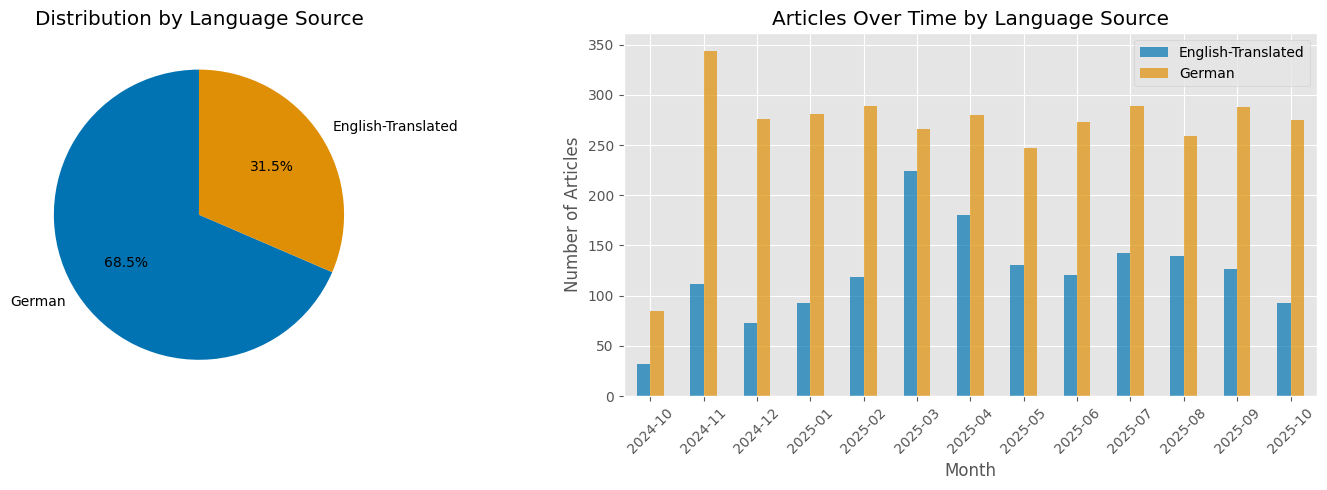


✓ MERGED DATASET VERIFICATION COMPLETE


In [62]:
print("="*60)
print("VERIFICATION AND SAMPLE OUTPUT")
print("="*60)

# Display merged dataset statistics
print(f"Merged dataset statistics:")
print(f"  Total articles: {len(merged_news_df)}")
print(f"  German articles: {len(merged_news_df[merged_news_df['language_source'] == 'German'])}")
print(f"  English-translated articles: {len(merged_news_df[merged_news_df['language_source'] == 'English-Translated'])}")
print(f"  Date range: {merged_news_df['publishedAt'].min()} to {merged_news_df['publishedAt'].max()}")

# Show sample merged headlines
print(f"\nSample merged headlines (showing both German originals and English translations):")
print("-" * 80)

# Show German headlines
german_samples = merged_news_df[merged_news_df['language_source'] == 'German'].head(3)
print(f"\nGerman headlines:")
for i, (idx, row) in enumerate(german_samples.iterrows()):
    print(f"\n{i+1}. [{row['source']}] {row['publishedAt'].strftime('%Y-%m-%d')}")
    print(f"    Title: {row['title']}")
    print(f"    Language: {row['language_source']}")

# Show English-translated headlines
english_samples = merged_news_df[merged_news_df['language_source'] == 'English-Translated'].head(3)
print(f"\nEnglish-translated headlines:")
for i, (idx, row) in enumerate(english_samples.iterrows()):
    print(f"\n{i+1}. [{row['source']}] {row['publishedAt'].strftime('%Y-%m-%d')}")
    print(f"    Original EN: {row['title_original']}")
    print(f"    Translated DE: {row['title']}")
    print(f"    Language: {row['language_source']}")

# Language source visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Language distribution
language_counts = merged_news_df['language_source'].value_counts()
axes[0].pie(language_counts.values, labels=language_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribution by Language Source')

# Timeline showing both sources
merged_news_df['month'] = merged_news_df['publishedAt'].dt.to_period('M')
timeline_data = merged_news_df.groupby(['month', 'language_source']).size().unstack(fill_value=0)
timeline_data.plot(kind='bar', ax=axes[1], alpha=0.7)
axes[1].set_title('Articles Over Time by Language Source')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Articles')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("✓ MERGED DATASET VERIFICATION COMPLETE")
print("="*60)


## 4. Initial Visualization Suite


### 4.1 Article Count Analysis


ARTICLE COUNT ANALYSIS
Total articles retrieved: 5038
Date range: 2024-10-21 11:20:36+00:00 to 2025-10-26 19:53:10+00:00
Average articles per day: 13.6

Top sources:
  Focus: 1338 articles (26.6%)
  Der Tagesspiegel: 1048 articles (20.8%)
  Bild: 687 articles (13.6%)
  NBC News: 644 articles (12.8%)
  CNN: 571 articles (11.3%)
  Die Zeit: 379 articles (7.5%)
  MSNBC: 131 articles (2.6%)
  Bloomberg: 107 articles (2.1%)
  Associated Press: 77 articles (1.5%)
  The Wall Street Journal: 31 articles (0.6%)


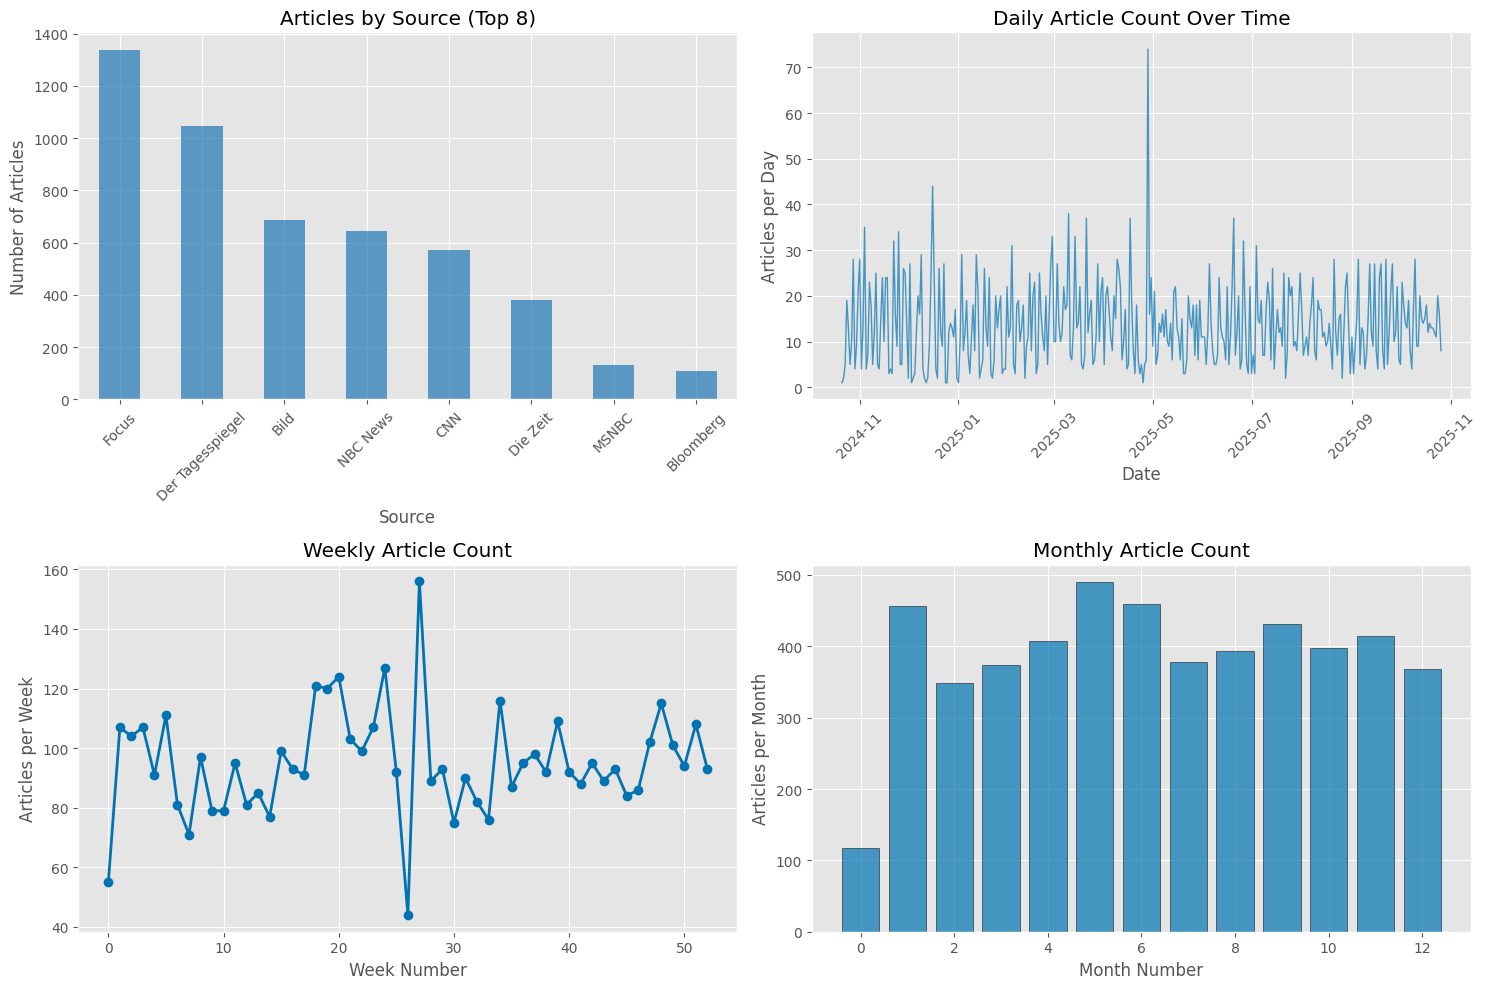


Temporal patterns:
  Peak daily count: 74 articles
  Average daily count: 13.6 articles
  Peak weekly count: 156 articles
  Average weekly count: 95.1 articles


In [63]:
# Summary statistics
print("="*60)
print("ARTICLE COUNT ANALYSIS")
print("="*60)
print(f"Total articles retrieved: {len(merged_news_df)}")
print(f"Date range: {merged_news_df['publishedAt'].min()} to {merged_news_df['publishedAt'].max()}")
print(f"Average articles per day: {len(merged_news_df) / ((merged_news_df['publishedAt'].max() - merged_news_df['publishedAt'].min()).days):.1f}")

# Source distribution
source_counts = merged_news_df['source'].value_counts()
print(f"\nTop sources:")
for source, count in source_counts.head(10).items():
    print(f"  {source}: {count} articles ({count/len(merged_news_df)*100:.1f}%)")

# Time series analysis
merged_news_df['date'] = merged_news_df['publishedAt'].dt.date
daily_counts = merged_news_df.groupby('date').size()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Source distribution
source_counts.head(8).plot(kind='bar', ax=axes[0,0], color='#1f77b4', alpha=0.7)
axes[0,0].set_title('Articles by Source (Top 8)')
axes[0,0].set_xlabel('Source')
axes[0,0].set_ylabel('Number of Articles')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Time series - daily counts
axes[0,1].plot(daily_counts.index, daily_counts.values, linewidth=1, alpha=0.7)
axes[0,1].set_title('Daily Article Count Over Time')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Articles per Day')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Weekly aggregation
weekly_counts = merged_news_df.groupby(merged_news_df['publishedAt'].dt.to_period('W')).size()
axes[1,0].plot(range(len(weekly_counts)), weekly_counts.values, marker='o', linewidth=2)
axes[1,0].set_title('Weekly Article Count')
axes[1,0].set_xlabel('Week Number')
axes[1,0].set_ylabel('Articles per Week')

# 4. Monthly aggregation
monthly_counts = merged_news_df.groupby(merged_news_df['publishedAt'].dt.to_period('M')).size()
axes[1,1].bar(range(len(monthly_counts)), monthly_counts.values, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Monthly Article Count')
axes[1,1].set_xlabel('Month Number')
axes[1,1].set_ylabel('Articles per Month')

plt.tight_layout()
plt.show()

print(f"\nTemporal patterns:")
print(f"  Peak daily count: {daily_counts.max()} articles")
print(f"  Average daily count: {daily_counts.mean():.1f} articles")
print(f"  Peak weekly count: {weekly_counts.max()} articles")
print(f"  Average weekly count: {weekly_counts.mean():.1f} articles")


### 4.2 Content Analysis

CONTENT ANALYSIS
Total words analyzed: 38150
Unique words: 12171

Top 20 most frequent words:
  trump: 466
  trumps: 244
  ukraine: 228
  deutschland: 184
  euro: 181
  strom: 148
  usa: 147
  geschäft: 133
  russland: 120
  zölle: 117
  politik: 110
  sagt: 101
  merz: 99
  china: 94
  putin: 89
  prozent: 86
  europa: 84
  macht: 79
  berlin: 78
  regierung: 78


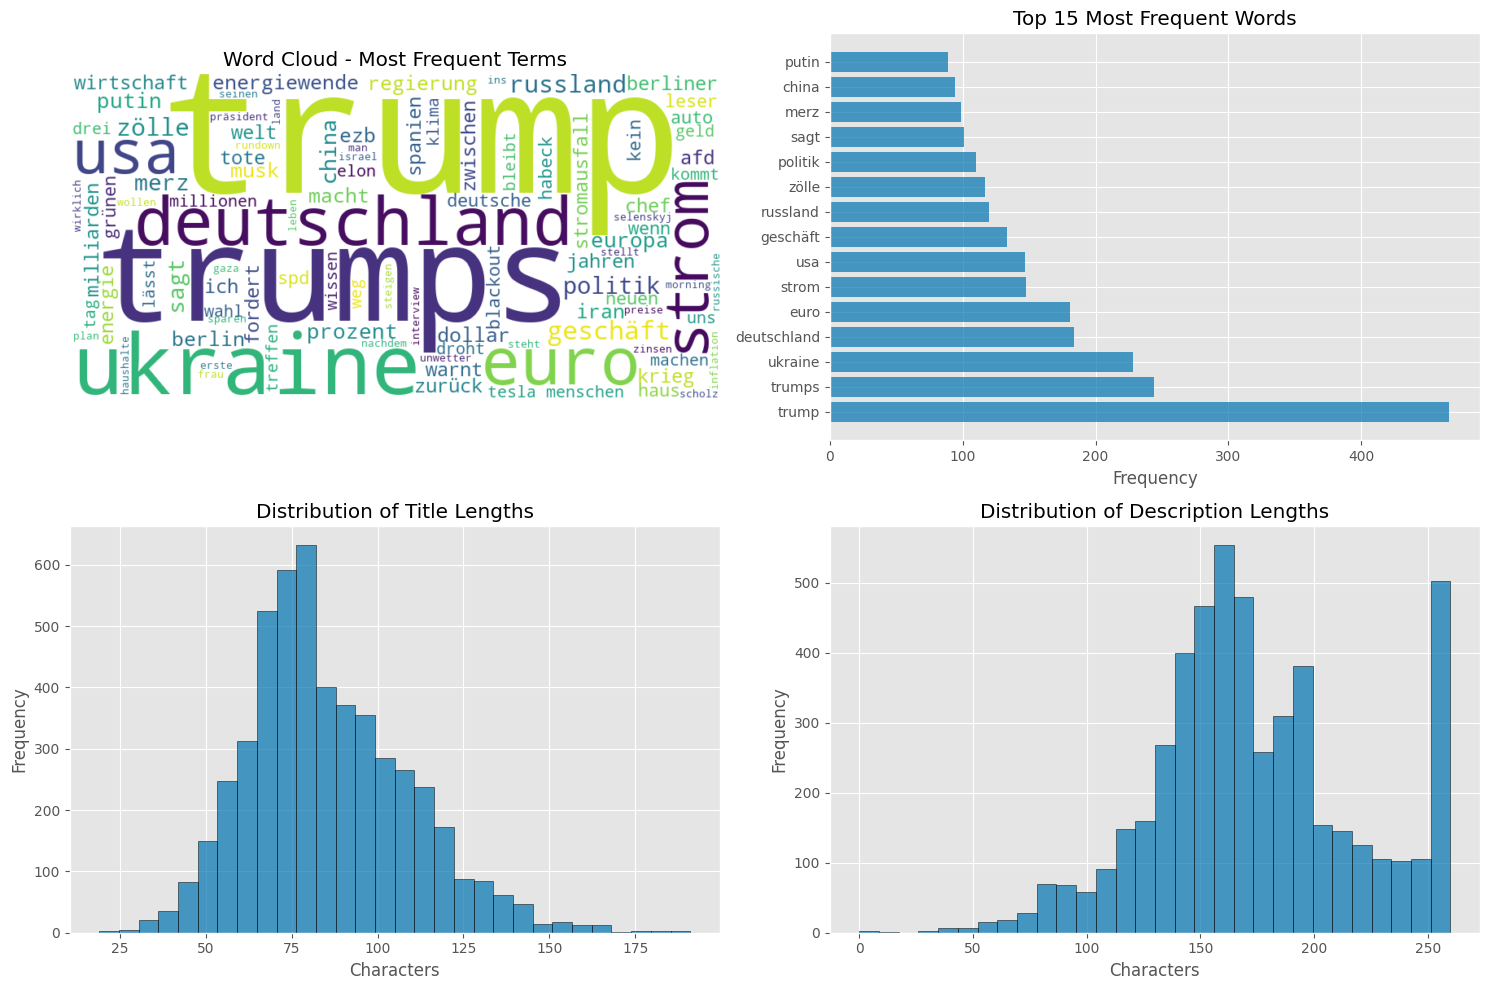


Text statistics:
  Average title length: 85.5 characters
  Average description length: 173.9 characters


In [68]:
# Combine all text for analysis
all_text = ' '.join(merged_news_df['title'].fillna(''))

# German stopwords (basic set)
german_stopwords = {
    'der', 'die', 'das', 'und', 'oder', 'aber', 'mit', 'von', 'zu', 'in', 'auf', 'für', 'an', 'ist', 'sind', 
    'war', 'wurde', 'werden', 'kann', 'können', 'muss', 'müssen', 'soll', 'sollen', 'hat', 'haben', 'nach',
    'über', 'unter', 'bei', 'durch', 'gegen', 'ohne', 'um', 'bis', 'seit', 'während', 'trotz', 'wegen',
    'ein', 'eine', 'einen', 'einer', 'einem', 'eines', 'nicht', 'nur', 'auch', 'noch', 'schon', 'erst',
    'mehr', 'weniger', 'viel', 'wenig', 'alle', 'jeder', 'jede', 'jedes', 'manche', 'einige', 'keine',
    'dieser', 'diese', 'dieses', 'jener', 'jene', 'jenes', 'welcher', 'welche', 'welches', 'was', 'wer',
    'wie', 'wo', 'wann', 'warum', 'weshalb', 'wozu', 'wofür', 'womit', 'wovon', 'wozu', 'wodurch',
    "sie", "dem", "jetzt", "hier", "den", "lesen", "finden", "thema", "sich", "aus", "vor", "als", "des",
    "wird", "zum", "neue", "vom", "doch", "will", "nun", "beim","gibt", "ihre", "wieder", "geht", "zur",
    "sein", "ihr", "zwei", "zeigt", "immer", "seine", "viele", "online", "könnte", "woche","jahr", "wir"
    "neuen", "weiter", "dass", "wir", "cnn"
}

# Clean and tokenize text
def clean_text(text):
    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-ZäöüßÄÖÜ\s]', ' ', text.lower())
    # Split into words and filter
    words = [word for word in text.split() if len(word) > 2 and word not in german_stopwords]
    return words

words = clean_text(all_text)
word_freq = Counter(words)

print("="*60)
print("CONTENT ANALYSIS")
print("="*60)
print(f"Total words analyzed: {len(words)}")
print(f"Unique words: {len(word_freq)}")

# Top words
print(f"\nTop 20 most frequent words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Word cloud
if len(word_freq) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                         max_words=100, colormap='viridis').generate_from_frequencies(word_freq)
    axes[0,0].imshow(wordcloud, interpolation='bilinear')
    axes[0,0].axis('off')
    axes[0,0].set_title('Word Cloud - Most Frequent Terms')

# 2. Top words bar chart
top_words = dict(word_freq.most_common(15))
axes[0,1].barh(range(len(top_words)), list(top_words.values()), alpha=0.7)
axes[0,1].set_yticks(range(len(top_words)))
axes[0,1].set_yticklabels(list(top_words.keys()))
axes[0,1].set_title('Top 15 Most Frequent Words')
axes[0,1].set_xlabel('Frequency')

# 3. Title length distribution
title_lengths = merged_news_df['title'].str.len()
axes[1,0].hist(title_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[1,0].set_title('Distribution of Title Lengths')
axes[1,0].set_xlabel('Characters')
axes[1,0].set_ylabel('Frequency')

# 4. Description length distribution
desc_lengths = merged_news_df['description'].str.len()
axes[1,1].hist(desc_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution of Description Lengths')
axes[1,1].set_xlabel('Characters')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nText statistics:")
print(f"  Average title length: {title_lengths.mean():.1f} characters")
print(f"  Average description length: {desc_lengths.mean():.1f} characters")


WORD SOURCE ANALYSIS: 'strom'
✓ Found 914 total occurrences of 'strom'
✓ Found in 7 different sources

📊 SOURCE FREQUENCY RANKING:
------------------------------------------------------------
 1. Der Tagesspiegel      306 occurrences ( 33.5%)
 2. Focus                 264 occurrences ( 28.9%)
 3. Bild                  228 occurrences ( 24.9%)
 4. Die Zeit              106 occurrences ( 11.6%)
 5. CNN                     6 occurrences (  0.7%)
 6. NBC News                3 occurrences (  0.3%)
 7. Bloomberg               1 occurrences (  0.1%)

📰 EXAMPLE HEADLINES BY SOURCE:
------------------------------------------------------------

🔸 Der Tagesspiegel (306 occurrences):
   • [2024-10-24] „Sie haben meine Tochter umgebracht“: Wie Menschen in Kuba die Tage ohne Strom erlebten
   • [2024-10-24] KI und Klima: Wird die Technologie der Umwelt helfen oder schaden?
   • [2024-10-25] „Aufschlag für besondere Netznutzung“: Stromkosten für Verbraucher könnten steigen

🔸 Focus (264 occurrences):

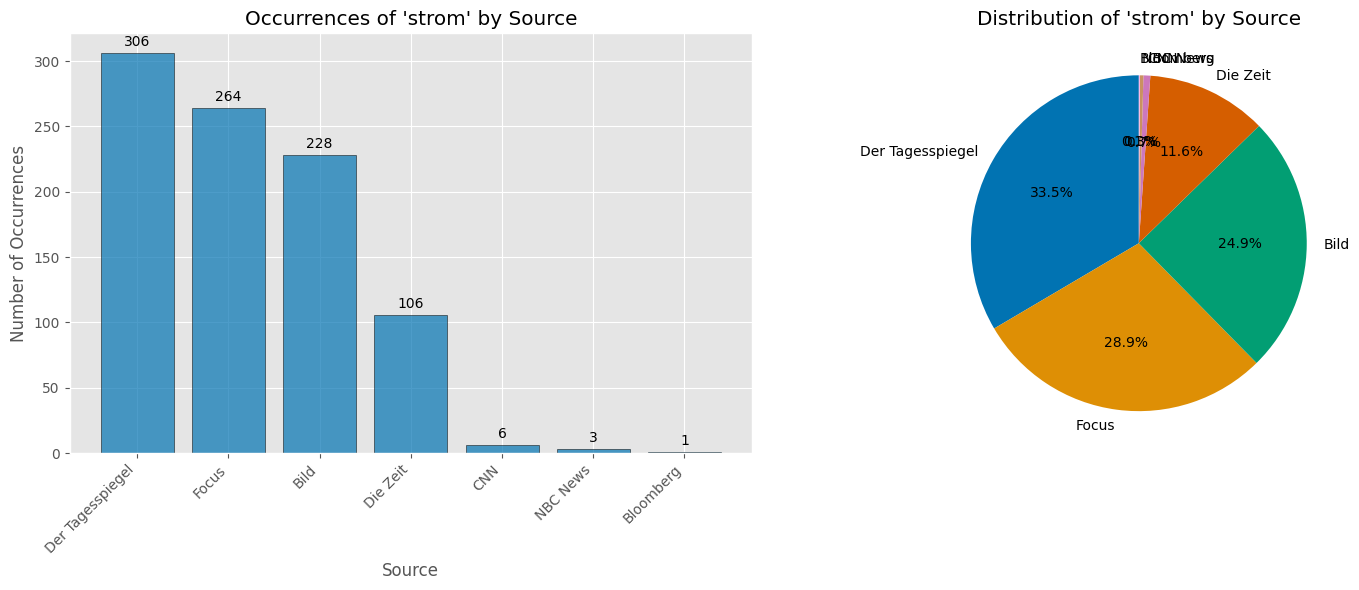

{'word': 'strom',
 'total_matches': 914,
 'source_counts': {'Der Tagesspiegel': 306,
  'Focus': 264,
  'Bild': 228,
  'Die Zeit': 106,
  'CNN': 6,
  'NBC News': 3,
  'Bloomberg': 1},
 'source_examples': {'Der Tagesspiegel': [{'title': '„Sie haben meine Tochter umgebracht“: Wie Menschen in Kuba die Tage ohne Strom erlebten',
    'date': '2024-10-24',
    'matches': 2},
   {'title': 'KI und Klima: Wird die Technologie der Umwelt helfen oder schaden?',
    'date': '2024-10-24',
    'matches': 1},
   {'title': '„Aufschlag für besondere Netznutzung“: Stromkosten für Verbraucher könnten steigen',
    'date': '2024-10-25',
    'matches': 2}],
  'Focus': [{'title': 'Künstliche Intelligenz - Energiemonster oder Gamechanger gegen den Klimawandel? Das sagen Experten',
    'date': '2024-10-25',
    'matches': 1},
   {'title': 'Präsentiert von CHIP und MEDION - Peis-Leistungs-Sieger: Die Heißluftfritteuse mit umfangreicher Ausstattung und geringem Stromverbrauch',
    'date': '2024-10-28',
    'mat

In [65]:
### 4.3 Word Source Analysis Tool

def analyze_word_by_source(word_to_search, case_sensitive=False):
    """
    Analyze which sources contain a specific word most frequently.
    
    Parameters:
    -----------
    word_to_search : str
        The word to search for in headlines and descriptions
    case_sensitive : bool, default False
        Whether the search should be case-sensitive
    
    Returns:
    --------
    dict: Analysis results with source counts and examples
    """
    print("="*60)
    print(f"WORD SOURCE ANALYSIS: '{word_to_search}'")
    print("="*60)
    
    # Prepare search parameters
    search_word = word_to_search if case_sensitive else word_to_search.lower()
    
    # Initialize counters
    source_counts = {}
    source_examples = {}
    total_matches = 0
    
    # Search through all articles
    for idx, row in merged_news_df.iterrows():
        source = row['source']
        
        # Combine title and description for search
        text_to_search = str(row['title']) + ' ' + str(row['description'] or '')
        
        # Apply case sensitivity
        if not case_sensitive:
            text_to_search = text_to_search.lower()
        
        # Count occurrences in this article
        matches_in_article = text_to_search.count(search_word)
        
        if matches_in_article > 0:
            total_matches += matches_in_article
            
            # Update source counts
            if source not in source_counts:
                source_counts[source] = 0
                source_examples[source] = []
            
            source_counts[source] += matches_in_article
            
            # Store example headlines (up to 3 per source)
            if len(source_examples[source]) < 3:
                source_examples[source].append({
                    'title': row['title'],
                    'date': row['publishedAt'].strftime('%Y-%m-%d'),
                    'matches': matches_in_article
                })
    
    # Display results
    if total_matches == 0:
        print(f"❌ No matches found for '{word_to_search}'")
        return None
    
    print(f"✓ Found {total_matches} total occurrences of '{word_to_search}'")
    print(f"✓ Found in {len(source_counts)} different sources")
    
    # Sort sources by frequency
    sorted_sources = sorted(source_counts.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n📊 SOURCE FREQUENCY RANKING:")
    print("-" * 60)
    for i, (source, count) in enumerate(sorted_sources, 1):
        percentage = (count / total_matches) * 100
        print(f"{i:2d}. {source:<20} {count:4d} occurrences ({percentage:5.1f}%)")
    
    # Show examples from top sources
    print(f"\n📰 EXAMPLE HEADLINES BY SOURCE:")
    print("-" * 60)
    for source, count in sorted_sources[:5]:  # Top 5 sources
        print(f"\n🔸 {source} ({count} occurrences):")
        for example in source_examples[source]:
            print(f"   • [{example['date']}] {example['title']}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Source frequency bar chart
    sources = [item[0] for item in sorted_sources]
    counts = [item[1] for item in sorted_sources]
    
    bars = axes[0].bar(range(len(sources)), counts, alpha=0.7, edgecolor='black')
    axes[0].set_title(f"Occurrences of '{word_to_search}' by Source")
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Number of Occurrences')
    axes[0].set_xticks(range(len(sources)))
    axes[0].set_xticklabels(sources, rotation=45, ha='right')
    
    # Add count labels on bars
    for i, count in enumerate(counts):
        axes[0].text(i, count + max(counts)*0.01, str(count), ha='center', va='bottom')
    
    # 2. Percentage pie chart
    if len(sources) > 1:
        axes[1].pie(counts, labels=sources, autopct='%1.1f%%', startangle=90)
        axes[1].set_title(f"Distribution of '{word_to_search}' by Source")
    else:
        axes[1].text(0.5, 0.5, f"Only found in\n{sources[0]}", 
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
        axes[1].set_title(f"Distribution of '{word_to_search}' by Source")
    
    plt.tight_layout()
    plt.show()
    
    # Return analysis results
    return {
        'word': word_to_search,
        'total_matches': total_matches,
        'source_counts': dict(sorted_sources),
        'source_examples': source_examples,
        'num_sources': len(source_counts)
    }

# Interactive function for easy word checking
def check_word(word):
    """
    Quick function to check a word's distribution across sources.
    Usage: check_word("Energie") or check_word("Solar")
    """
    return analyze_word_by_source("strom")

check_word("strom")


## 5. BERTopic Analysis for Topic Discovery


BERTOPIC ANALYSIS (WORKING VERSION)
Prepared 5038 documents for topic modeling
Initializing BERTopic with German language model...
Fitting BERTopic model...


2025-10-27 09:44:55,050 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 158/158 [00:09<00:00, 16.00it/s]
2025-10-27 09:45:08,923 - BERTopic - Embedding - Completed ✓
2025-10-27 09:45:08,924 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-27 09:45:18,193 - BERTopic - Dimensionality - Completed ✓
2025-10-27 09:45:18,194 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-27 09:45:19,268 - BERTopic - Cluster - Completed ✓
2025-10-27 09:45:19,272 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-27 09:45:19,402 - BERTopic - Representation - Completed ✓



✓ BERTopic analysis complete!
✓ Discovered 105 topics

Topic Overview:
------------------------------------------------------------
Topic -1: 1599 documents - -1_der_die_und_in
Topic  0:  152 documents - 0_tariffs_trump_zölle_trade
Topic  1:  144 documents - 1_klima_klimaschutz_eu_baku
Topic  2:  139 documents - 2_elbvertiefung_berlin_hamburg_am
Topic  3:  112 documents - 3_putin_ukraine_trump_vladimir
Topic  4:  106 documents - 4_wirtschaft_deutschland_deutsche_das
Topic  5:   90 documents - 5_ezb_zinsen_tagesgeld_senkt
Topic  6:   88 documents - 6_iran_israel_nuclear_teheran
Topic  7:   79 documents - 7_gaza_israel_gazastreifen_hamas
Topic  8:   76 documents - 8_stromsteuer_strompreis_senken_stromkosten
Topic  9:   64 documents - 9_spanien_blackout_portugal_stromausfall
Topic 10:   61 documents - 10_china_xi_chinas_chinese
Topic 11:   59 documents - 11_trump_donald_faktencheck_his
Topic 12:   57 documents - 12_suv_bmw_hybrid_nissan
Topic 13:   54 documents - 13_lebensmittel_sie_wie_

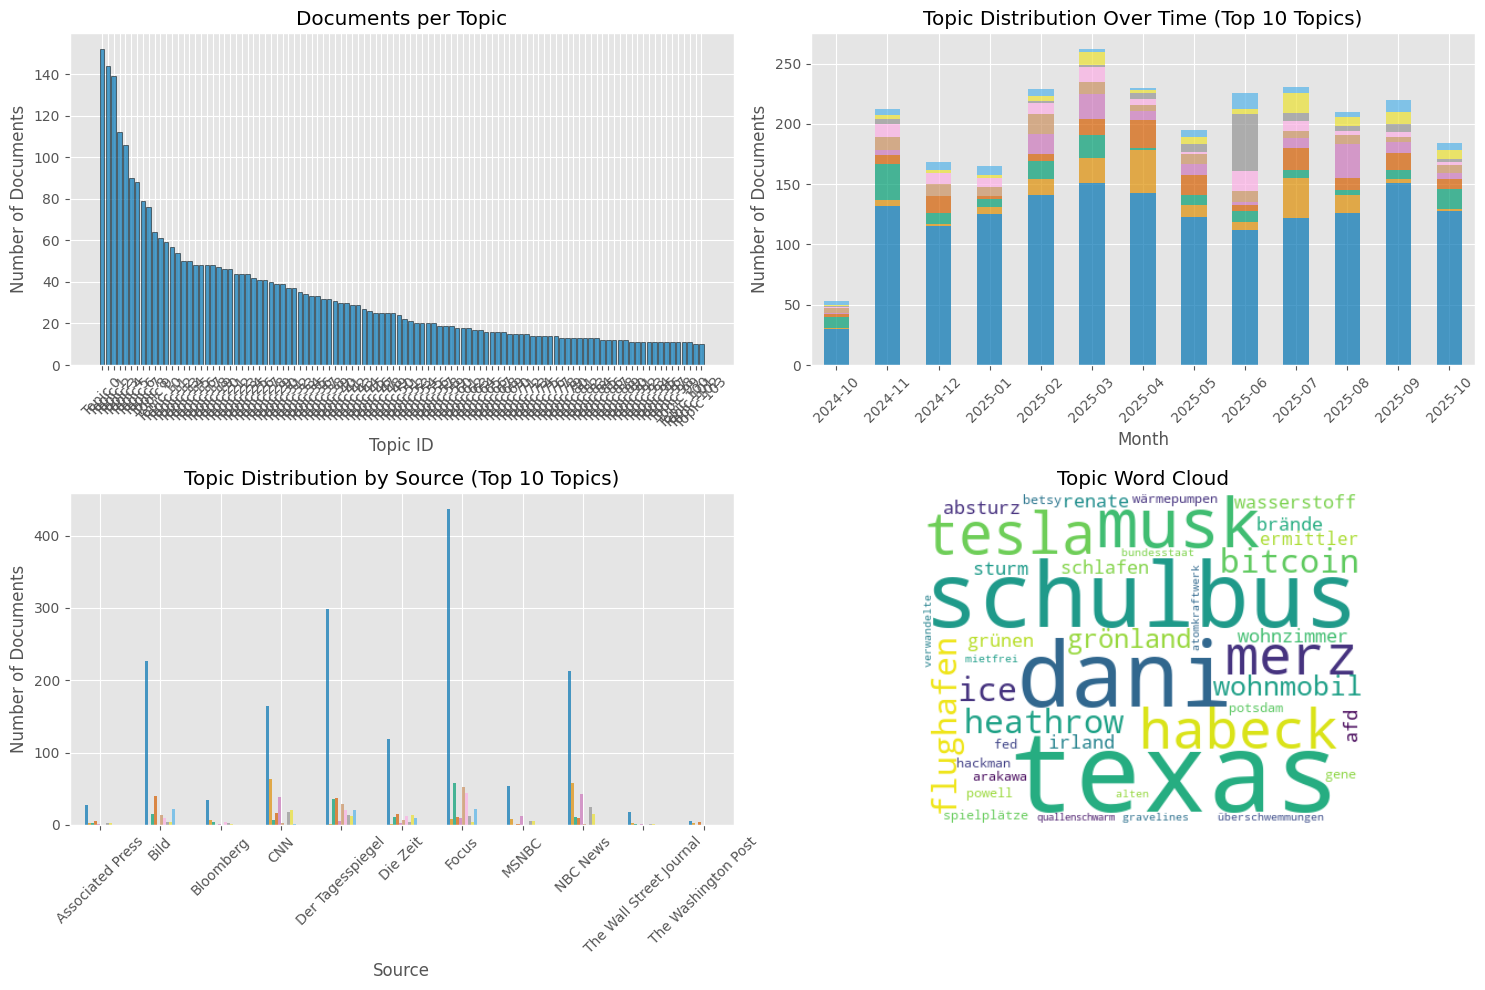


✓ BERTopic analysis complete!
✓ Use the topic information above to identify relevant topics for:
  - Energy production (Kraftwerk, Solar, Wind, etc.)
  - Energy consumption (Verbrauch, Bedarf, etc.)
  - Energy policy/pricing (Preis, Politik, etc.)


In [66]:
# ✅ WORKING BERTopic Analysis - Use This Cell Instead!
if bertopic_available and len(merged_news_df) > 0:
    print("="*60)
    print("BERTOPIC ANALYSIS (WORKING VERSION)")
    print("="*60)
    
    # Prepare documents for BERTopic
    documents = []
    for idx, row in merged_news_df.iterrows():
        # Combine title and description
        doc = str(row['title'])
        if pd.notna(row['description']) and len(str(row['description'])) > 0:
            doc += " " + str(row['description'])
        documents.append(doc)
    
    print(f"Prepared {len(documents)} documents for topic modeling")
    
    # Initialize BERTopic with German-compatible model
    print("Initializing BERTopic with German language model...")
    model = BERTopic(
        embedding_model="paraphrase-multilingual-MiniLM-L12-v2",
        language="german",
        calculate_probabilities=True,
        verbose=True
    )
    
    # Fit the model
    print("Fitting BERTopic model...")
    topics, probs = model.fit_transform(documents)
    
    # Get topic information
    topic_info = model.get_topic_info()
    print(f"\n✓ BERTopic analysis complete!")
    print(f"✓ Discovered {len(topic_info)} topics")
    
    # Display topic information
    print(f"\nTopic Overview:")
    print("-" * 60)
    for idx, row in topic_info.iterrows():
        print(f"Topic {row['Topic']:2d}: {row['Count']:4d} documents - {row['Name']}")
    
    # Show detailed topics - FIXED VERSION
    print(f"\nDetailed Topic Analysis:")
    print("=" * 60)
    
    # Get unique topic IDs from the topics array
    unique_topics = np.unique(topics)
    print(f"Unique topics found: {unique_topics}")
    
    for topic_id in unique_topics:
        if topic_id == -1:  # Skip outlier topic
            continue
            
        print(f"\nTopic {topic_id}:")
        print("-" * 40)
        
        # Get top words for this topic
        words = model.get_topic(topic_id)
        if words:
            print("Top words:", ", ".join([word[0] for word in words[:10]]))
        
        # Get representative documents - FIXED: use proper boolean indexing
        topic_mask = topics == topic_id
        topic_docs = merged_news_df[topic_mask]
        if len(topic_docs) > 0:
            print(f"Sample headlines ({len(topic_docs)} total):")
            for i, (idx, row) in enumerate(topic_docs.head(5).iterrows()):
                print(f"  {i+1}. [{row['source']}] {row['title']}")
    
    # Create topic visualization - IMPROVED VERSION
    print(f"\nGenerating topic visualizations...")
    
    # Topic size visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Topic sizes - FIXED: calculate counts properly
    topic_counts = []
    topic_labels = []
    for topic_id in unique_topics:
        if topic_id != -1:  # Skip outlier topic
            count = np.sum(topics == topic_id)
            topic_counts.append(count)
            topic_labels.append(f"Topic {topic_id}")
    
    axes[0,0].bar(range(len(topic_counts)), topic_counts, alpha=0.7, edgecolor='black')
    axes[0,0].set_title('Documents per Topic')
    axes[0,0].set_xlabel('Topic ID')
    axes[0,0].set_ylabel('Number of Documents')
    axes[0,0].set_xticks(range(len(topic_counts)))
    axes[0,0].set_xticklabels(topic_labels, rotation=45)
    
    # 2. Topic distribution over time - IMPROVED: Remove legend, show only top topics
    merged_news_df['topic'] = topics
    merged_news_df['month'] = merged_news_df['publishedAt'].dt.to_period('M')
    topic_time = merged_news_df.groupby(['month', 'topic']).size().unstack(fill_value=0)
    
    if len(topic_time.columns) > 0:
        # Show only top 10 topics to avoid clutter
        top_topics = topic_time.sum().nlargest(10).index
        topic_time_top = topic_time[top_topics]
        
        topic_time_top.plot(kind='bar', stacked=True, ax=axes[0,1], alpha=0.7, legend=False)
        axes[0,1].set_title('Topic Distribution Over Time (Top 10 Topics)')
        axes[0,1].set_xlabel('Month')
        axes[0,1].set_ylabel('Number of Documents')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Topic distribution by source - IMPROVED: Remove legend, show only top topics
    topic_source = merged_news_df.groupby(['source', 'topic']).size().unstack(fill_value=0)
    if len(topic_source.columns) > 0:
        # Show only top 10 topics to avoid clutter
        top_topics_source = topic_source.sum().nlargest(10).index
        topic_source_top = topic_source[top_topics_source]
        
        topic_source_top.plot(kind='bar', ax=axes[1,0], alpha=0.7, legend=False)
        axes[1,0].set_title('Topic Distribution by Source (Top 10 Topics)')
        axes[1,0].set_xlabel('Source')
        axes[1,0].set_ylabel('Number of Documents')
        axes[1,0].tick_params(axis='x', rotation=45)
    
    # 4. Topic word cloud - IMPROVED: Show word cloud instead of empty plot
    try:
        # Get all words from all topics
        all_words = []
        for topic_id in unique_topics:
            if topic_id != -1:  # Skip outlier topic
                words = model.get_topic(topic_id)
                if words:
                    # Add words weighted by their c-TF-IDF scores
                    for word, score in words[:5]:  # Top 5 words per topic
                        all_words.extend([word] * int(score * 10))  # Weight by score
        
        if all_words:
            # Create word cloud
            from wordcloud import WordCloud
            wordcloud = WordCloud(width=400, height=300, background_color='white', 
                                max_words=50, colormap='viridis').generate(' '.join(all_words))
            axes[1,1].imshow(wordcloud, interpolation='bilinear')
            axes[1,1].axis('off')
            axes[1,1].set_title('Topic Word Cloud')
        else:
            axes[1,1].text(0.5, 0.5, 'No words available\nfor word cloud', 
                           ha='center', va='center', transform=axes[1,1].transAxes)
            axes[1,1].set_title('Topic Word Cloud')
    except Exception as e:
        axes[1,1].text(0.5, 0.5, f'Word cloud error:\n{str(e)[:50]}...', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Topic Word Cloud')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ BERTopic analysis complete!")
    print(f"✓ Use the topic information above to identify relevant topics for:")
    print(f"  - Energy production (Kraftwerk, Solar, Wind, etc.)")
    print(f"  - Energy consumption (Verbrauch, Bedarf, etc.)")
    print(f"  - Energy policy/pricing (Preis, Politik, etc.)")
    
else:
    print("⚠️  BERTopic not available or no data to analyze")
    print("Please install BERTopic: pip install bertopic sentence-transformers")
